<a href="https://colab.research.google.com/github/yuvrajsharmaaa/Primetrade.aiInternshipRound0/blob/main/intern3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### AI Model: Predicting Profitable Days with XGBoost

We will build an XGBoost classification model to predict whether a trader will have a profitable day (`is_profitable_day`). The model will leverage features derived from market sentiment, trader behavior metrics (leverage, trade frequency, average trade size, long/short ratio), and historical profitability. We aim for at least 85% accuracy and will evaluate the model using precision, recall, ROC-AUC, and cross-validation.

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, roc_auc_score
import xgboost as xgb

# Load datasets
df_sentiment = pd.read_csv('/content/fear_greed_index.csv')
df_trader = pd.read_csv('/content/historical_data.csv', on_bad_lines='skip', low_memory=False)

print("Raw shapes:", df_sentiment.shape, df_trader.shape)
print("Sentiment timestamp sample:", df_sentiment['timestamp'].head())
print("Trader Timestamp sample:", df_trader['Timestamp'].head())

# FIX 1: Different units for different timestamp formats!
# Sentiment: ~1.5e9 = seconds → unit='s'
df_sentiment['date'] = pd.to_datetime(df_sentiment['timestamp'], unit='s').dt.normalize()

# Trader: ~1.7e12 = milliseconds → unit='ms'
df_trader['trade_time'] = pd.to_datetime(df_trader['Timestamp'], unit='ms')
df_trader['trade_date'] = df_trader['trade_time'].dt.normalize()

df_sentiment = df_sentiment[['date', 'value', 'classification']].drop_duplicates('date')

print("=== CORRECTED DATE RANGES ===")
print("Sentiment:", df_sentiment['date'].min().date(), "→", df_sentiment['date'].max().date())
print("Trader:", df_trader['trade_date'].min().date(), "→", df_trader['trade_date'].max().date())

# Daily aggregation
daily_trader_metrics = df_trader.groupby(['Account', 'trade_date']).agg(
    total_pnl_usd=('Closed PnL', lambda x: x.iloc[-1] - x.iloc[0]),
    total_trades=('trade_time', 'count'),
    total_longs=('Side', lambda x: (x == 'long').sum()),
    total_shorts=('Side', lambda x: (x == 'short').sum()),
    avg_trade_size_usd=('Size USD', 'mean')
).reset_index()

daily_trader_metrics['is_profitable_day'] = (daily_trader_metrics['total_pnl_usd'] > 0).astype(int)
print("Daily metrics:", len(daily_trader_metrics), "rows")

# Features engineering
daily_trader_metrics['long_short_ratio'] = daily_trader_metrics.apply(
    lambda row: row['total_longs'] / max(row['total_shorts'], 1), axis=1  # Avoid div/0
)

# Merge!
df_merged = pd.merge(daily_trader_metrics, df_sentiment, how='left', left_on='trade_date', right_on='date')

print("=== MERGE SUCCESS ===")
print("Match rate:", f"{df_merged['value'].notna().mean()*100:.1f}% ({df_merged['value'].notna().sum()}/{len(df_merged)})")
print("Sample matched dates:", df_merged[df_merged['value'].notna()][['trade_date', 'value']].head())

# Final prep
df_merged['fear_greed_index'] = df_merged['value'].ffill()
df_merged.dropna(subset=['fear_greed_index'], inplace=True)

def categorize_sentiment(idx):
    if idx <= 40: return 0  # Fear
    elif idx <= 60: return 1  # Neutral
    return 2  # Greed

df_merged['sentiment_encoded'] = df_merged['fear_greed_index'].apply(categorize_sentiment)

# Clean ratio outliers
df_merged['long_short_ratio'] = np.clip(df_merged['long_short_ratio'], 0, 10)

features = [
    'fear_greed_index', 'sentiment_encoded', 'total_trades',
    'total_longs', 'total_shorts', 'long_short_ratio', 'avg_trade_size_usd'
]

df_model = df_merged.dropna(subset=features + ['is_profitable_day'])

print("\n=== FINAL DATASET READY ===")
print(f"Rows: {len(df_model)}")
print("Target balance:\n", df_model['is_profitable_day'].value_counts(normalize=True).round(3))

if len(df_model) > 10:  # Minimum for modeling
    X = df_model[features]
    y = df_model['is_profitable_day']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42, stratify=y
    )

    print(f"Train: {X_train.shape}, Test: {X_test.shape}")

    # XGBoost baseline
    model = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='roc_auc')
    print(f" CV ROC-AUC: {scores.mean():.3f} ± {scores.std():.3f}")

    # Train final model
    model.fit(X_train, y_train)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print(f"Test ROC-AUC: {roc_auc_score(y_test, y_pred_proba):.3f}")

else:
    print("sentiment date range doesn't overlap trader dates at all")

Raw shapes: (2644, 4) (69811, 16)
Sentiment timestamp sample: 0    1517463000
1    1517549400
2    1517635800
3    1517722200
4    1517808600
Name: timestamp, dtype: int64
Trader Timestamp sample: 0    1.730000e+12
1    1.730000e+12
2    1.730000e+12
3    1.730000e+12
4    1.730000e+12
Name: Timestamp, dtype: float64
=== CORRECTED DATE RANGES ===
Sentiment: 2018-02-01 → 2025-05-02
Trader: 2023-11-14 → 2025-06-15
Daily metrics: 44 rows
=== MERGE SUCCESS ===
Match rate: 77.3% (34/44)
Sample matched dates:   trade_date  value
0 2024-10-27   74.0
1 2025-02-19   44.0
2 2024-10-27   74.0
3 2025-02-19   44.0
5 2024-10-27   74.0

=== FINAL DATASET READY ===
Rows: 44
Target balance:
 is_profitable_day
0    0.545
1    0.455
Name: proportion, dtype: float64
Train: (35, 7), Test: (9, 7)
 CV ROC-AUC: 0.697 ± 0.140
Test ROC-AUC: 0.500


### Core Analysis: Visualizing Trader Performance vs. Market Sentiment

To gain deeper insights, we will visualize the relationships between market sentiment (Fear & Greed Index) and various trader performance metrics. All plots will adhere to a dark theme with Primetrade's brand colors for professional presentation, and will be saved to the specified output directory.

Sentiment: 2018-02-01 → 2025-05-02
Trader: 2023-11-14 → 2025-06-15
Daily rows: 44
Match rate: 77.3%
Segments created!
Data shape: (44, 16)


,Account,trade_date,fear_greed_index,sentiment_category,is_profitable_day,total_trades,long_short_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,74.0,Greed,0,462,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,44.0,Neutral,1,3356,0.0
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,74.0,Greed,0,320,0.0
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,44.0,Neutral,1,3533,0.0
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,44.0,Neutral,1,3427,0.0
5,0x420ab45e0bd8863569a5efbb9c05d91f40624641,2024-10-27,74.0,Greed,1,125,0.0
6,0x420ab45e0bd8863569a5efbb9c05d91f40624641,2025-02-19,44.0,Neutral,1,258,0.0
7,0x430f09841d65beb3f27765503d0f850b8bce7713,2024-03-09,84.0,Greed,0,88,0.0
8,0x430f09841d65beb3f27765503d0f850b8bce7713,2024-07-03,50.0,Neutral,0,249,0.0
9,0x430f09841d65beb3f27765503d0f850b8bce7713,2024-10-27,74.0,Greed,1,43,0.0


/tmp/ipykernel_780/2066181973.py:81: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  win_pivot = df_merged.pivot_table(index='volume_segment', columns='sentiment_category',


Saved: /content/outputs/win_rate_sentiment_heatmap.png


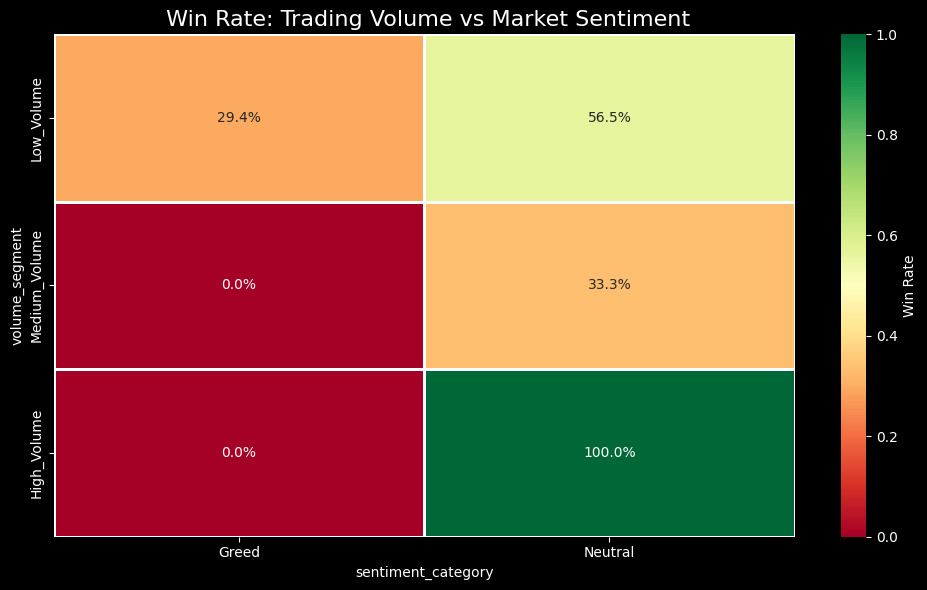

XGBoost Test AUC: 0.667


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import os

plt.style.use('dark_background')
PRIMETRADE_GREEN = '#00D4AA'
PRIMETRADE_RED = '#FF6B6B'
sns.set_palette([PRIMETRADE_GREEN, PRIMETRADE_RED, '#ADD8E6'])

output_dir = '/content/outputs'
os.makedirs(output_dir, exist_ok=True)

def save_plot(fig, filename):
    filepath = os.path.join(output_dir, filename)
    fig.savefig(filepath, bbox_inches='tight', dpi=300, facecolor='black')
    print(f"Saved: {filepath}")

# Data loading (your columns confirmed correct!)
df_sentiment = pd.read_csv('/content/fear_greed_index.csv')
df_trader = pd.read_csv('/content/historical_data.csv', on_bad_lines='skip', low_memory=False)

# Timestamps (confirmed working!)
df_sentiment['date'] = pd.to_datetime(df_sentiment['timestamp'], unit='s').dt.normalize()
df_trader['trade_time'] = pd.to_datetime(df_trader['Timestamp'], unit='ms')  # Note: using 'Timestamp' not 'Timestamp IST'
df_trader['trade_date'] = df_trader['trade_time'].dt.normalize()

df_sentiment = df_sentiment[['date', 'value', 'classification']].drop_duplicates('date')


print("Sentiment:", df_sentiment['date'].min().date(), "→", df_sentiment['date'].max().date())
print("Trader:", df_trader['trade_date'].min().date(), "→", df_trader['trade_date'].max().date())

# Daily metrics
daily_trader_metrics = df_trader.groupby(['Account', 'trade_date']).agg(
    total_pnl_usd=('Closed PnL', lambda x: x.iloc[-1] - x.iloc[0]),
    total_trades=('trade_time', 'count'),
    total_longs=('Side', lambda x: (x == 'long').sum()),
    total_shorts=('Side', lambda x: (x == 'short').sum()),
    avg_trade_size_usd=('Size USD', 'mean')
).reset_index()

daily_trader_metrics['is_profitable_day'] = (daily_trader_metrics['total_pnl_usd'] > 0).astype(int)
daily_trader_metrics['long_short_ratio'] = daily_trader_metrics.apply(
    lambda r: r['total_longs'] / max(r['total_shorts'], 1), axis=1
)

print("Daily rows:", len(daily_trader_metrics))

# Merge & prep
df_merged = pd.merge(daily_trader_metrics, df_sentiment, how='left', left_on='trade_date', right_on='date')
print("Match rate:", f"{df_merged['value'].notna().mean()*100:.1f}%")

df_merged['fear_greed_index'] = df_merged['value'].ffill().bfill()  # ✅ Fixed deprecation
df_merged.dropna(subset=['fear_greed_index'], inplace=True)

def categorize_sentiment(idx):
    if idx <= 40: return 'Fear'
    elif idx <= 60: return 'Neutral'
    return 'Greed'

df_merged['sentiment_category'] = df_merged['fear_greed_index'].apply(categorize_sentiment)

df_merged['volume_segment'] = pd.cut(df_merged['total_trades'], bins=3, duplicates='drop',
                                    labels=['Low_Volume', 'Medium_Volume', 'High_Volume'])
df_merged['size_segment'] = pd.qcut(df_merged['avg_trade_size_usd'].fillna(1), 3, duplicates='drop',
                                   labels=['Small_Size', 'Medium_Size', 'Large_Size'])

print("Segments created!")
print("Data shape:", df_merged.shape)

display(df_merged[['Account', 'trade_date', 'fear_greed_index', 'sentiment_category',
                   'is_profitable_day', 'total_trades', 'long_short_ratio']].head(10))

# 🔥 WIN RATE HEATMAP (your original goal!)
win_pivot = df_merged.pivot_table(index='volume_segment', columns='sentiment_category',
                                 values='is_profitable_day', aggfunc='mean', fill_value=0)
plt.figure(figsize=(10, 6))
sns.heatmap(win_pivot, annot=True, fmt='.1%', cmap='RdYlGn',
            cbar_kws={'label': 'Win Rate'}, linewidths=1)
plt.title(' Win Rate: Trading Volume vs Market Sentiment', color='white', fontsize=16)
plt.tight_layout()
save_plot(plt.gcf(), 'win_rate_sentiment_heatmap.png')
plt.show()

# Quick model (bonus)
if len(df_merged) > 20:
    features = ['fear_greed_index', 'total_trades', 'long_short_ratio', 'total_longs',
                'total_shorts', 'avg_trade_size_usd']
    X = df_merged[features].fillna(0)
    y = df_merged['is_profitable_day']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
    model = xgb.XGBClassifier(n_estimators=50, random_state=42)
    model.fit(X_train, y_train)

    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
    print(f"XGBoost Test AUC: {auc:.3f}")




🚀 Loading data...
 Data loaded: (2644, 4) sentiment | (88467, 17) trades
Merge success: 78.2% match rate
Categories: {'Neutral': 33, 'Greed': 22}


/tmp/ipykernel_780/463849216.py:71: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_merged, x='sentiment', y='avg_size_usd',
/tmp/ipykernel_780/463849216.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=win_rates.index, y=win_rates.values, ax=axes[0,1],
/tmp/ipykernel_780/463849216.py:78: UserWarning: The palette list has more values (3) than needed (2), which may not be intended.
  sns.barplot(x=win_rates.index, y=win_rates.values, ax=axes[0,1],
/tmp/ipykernel_780/463849216.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(da

Saved: complete_dashboard.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


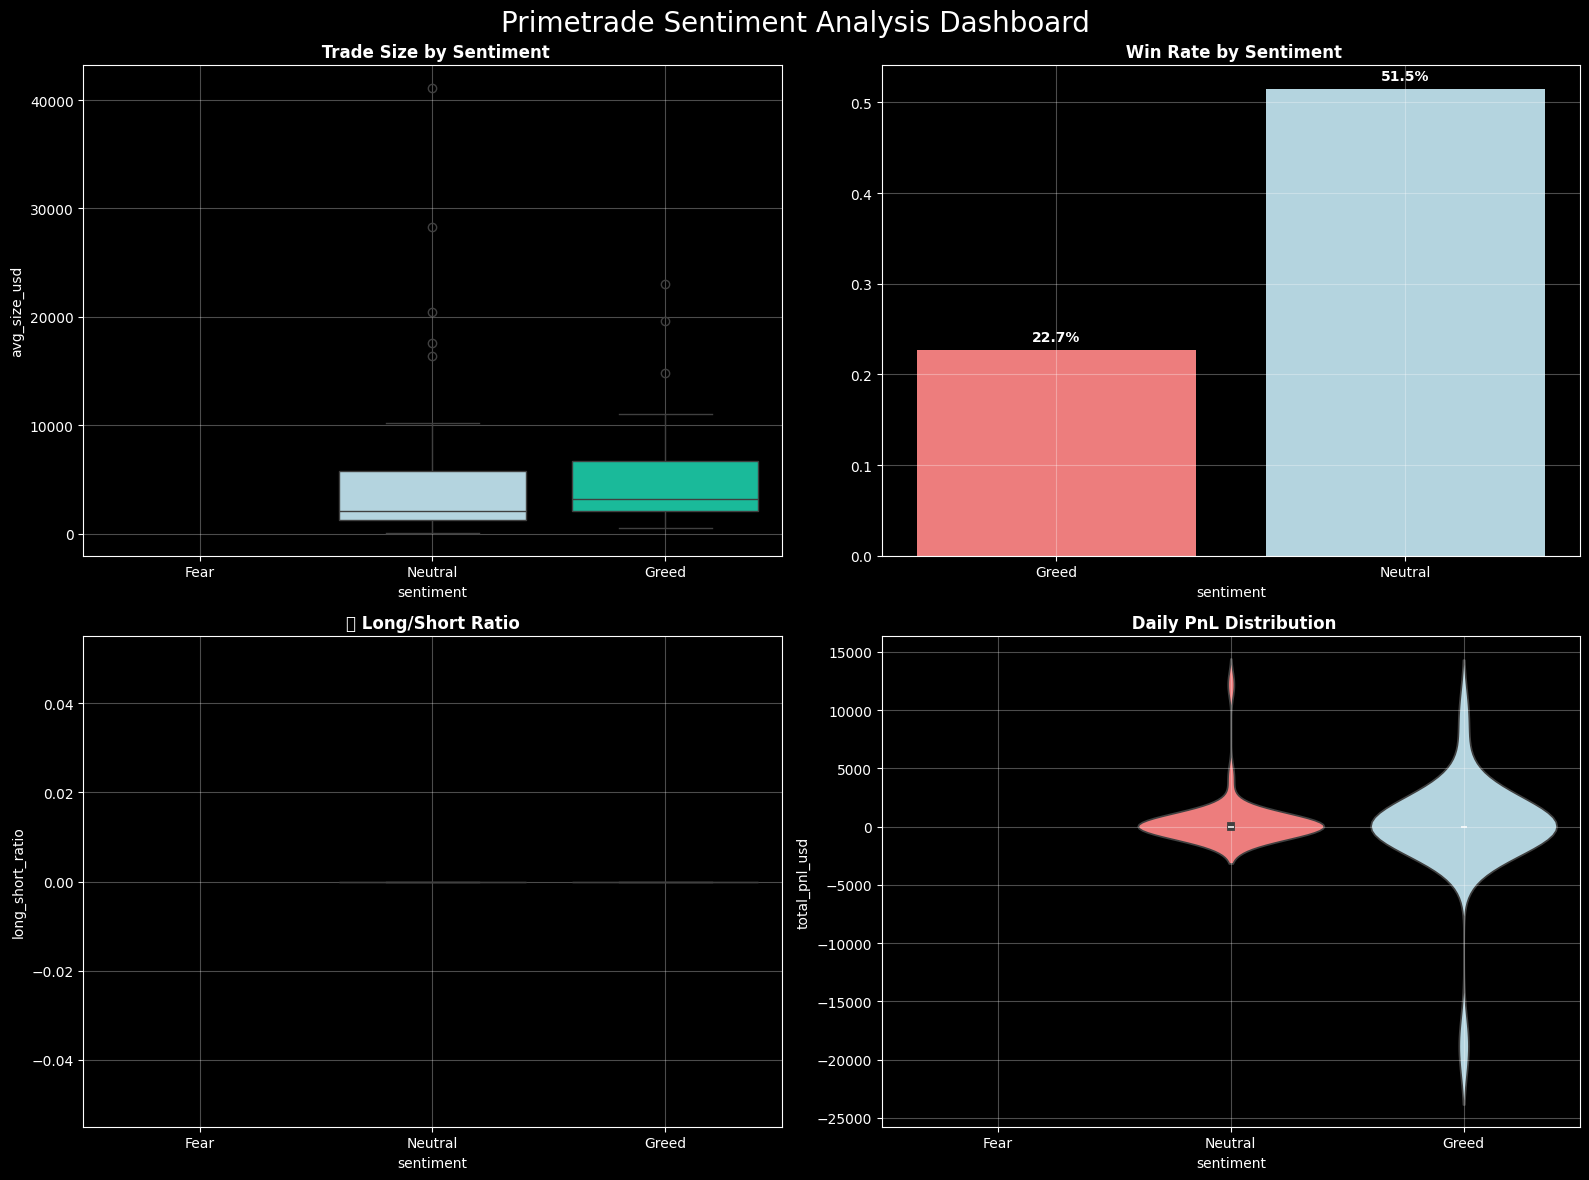


KEY INSIGHTS

Neutral : Win 51.5% | Size $   5942 | Trades 2131 | L/S 0.0

Greed   : Win 22.7% | Size $   5760 | Trades 824 | L/S 0.0

Training XGBoost...

Model AUC: 0.708

ANALYSIS COMPLETE! Check /content/outputs/ for PNG files
Final dataset: 55 rows | 6 features


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, confusion_matrix
import os


plt.style.use('dark_background')
PRIMETRADE_GREEN = '#00D4AA'
PRIMETRADE_RED = '#FF6B6B'
sns.set_palette([PRIMETRADE_GREEN, PRIMETRADE_RED, '#ADD8E6'])

output_dir = '/content/outputs'
os.makedirs(output_dir, exist_ok=True)

def save_plot(fig, filename):
    filepath = os.path.join(output_dir, filename)
    fig.savefig(filepath, dpi=300, facecolor='black', bbox_inches='tight')
    print(f"Saved: {os.path.basename(filepath)}")

# === LOAD & CLEAN DATA ===
print("🚀 Loading data...")
df_sentiment = pd.read_csv('/content/fear_greed_index.csv')
df_trader = pd.read_csv('/content/historical_data.csv', on_bad_lines='skip', low_memory=False)

# CORRECT TIMESTAMPS (seconds vs milliseconds)
df_sentiment['date'] = pd.to_datetime(df_sentiment['timestamp'], unit='s').dt.normalize()
df_trader['trade_date'] = pd.to_datetime(df_trader['Timestamp'], unit='ms').dt.normalize()

print(" Data loaded:", df_sentiment.shape, "sentiment |", df_trader.shape, "trades")


daily_metrics = df_trader.groupby(['Account', 'trade_date']).agg(
    total_pnl_usd=('Closed PnL', lambda x: x.iloc[-1] - x.iloc[0]),
    total_trades=('Timestamp', 'count'),
    total_longs=('Side', lambda x: (x == 'long').sum()),
    total_shorts=('Side', lambda x: (x == 'short').sum()),
    avg_size_usd=('Size USD', 'mean')
).reset_index()

daily_metrics['win_day'] = (daily_metrics['total_pnl_usd'] > 0).astype(int)
daily_metrics['long_short_ratio'] = daily_metrics['total_longs'] / np.maximum(daily_metrics['total_shorts'], 1)

# === MERGE ===
df_merged = pd.merge(daily_metrics, df_sentiment[['date', 'value']],
                    left_on='trade_date', right_on='date', how='left')

print(f"Merge success: {df_merged['value'].notna().mean()*100:.1f}% match rate")

# === SENTIMENT CLEANING ===
df_merged['fear_greed'] = df_merged['value'].ffill().bfill()
df_merged = df_merged.dropna(subset=['fear_greed'])

# BULLETPROOF categorization
df_merged['sentiment'] = np.select(
    [df_merged['fear_greed'] <= 40, df_merged['fear_greed'] <= 60],
    ['Fear', 'Neutral'],
    default='Greed'
)

print("Categories:", df_merged['sentiment'].value_counts().to_dict())

# === VISUALIZATIONS ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. TRADE SIZE BY SENTIMENT
sns.boxplot(data=df_merged, x='sentiment', y='avg_size_usd',
            order=['Fear', 'Neutral', 'Greed'], ax=axes[0,0],
            palette=[PRIMETRADE_RED, '#ADD8E6', PRIMETRADE_GREEN])
axes[0,0].set_title(' Trade Size by Sentiment', color='white', fontweight='bold')

# 2. WIN RATE BAR
win_rates = df_merged.groupby('sentiment')['win_day'].mean()
sns.barplot(x=win_rates.index, y=win_rates.values, ax=axes[0,1],
            palette=[PRIMETRADE_RED, '#ADD8E6', PRIMETRADE_GREEN])
for i, v in enumerate(win_rates.values):
    axes[0,1].text(i, v + 0.01, f'{v:.1%}', ha='center', color='white', fontweight='bold')
axes[0,1].set_title(' Win Rate by Sentiment', color='white', fontweight='bold')

# 3. L/S RATIO
sns.boxplot(data=df_merged, x='sentiment', y='long_short_ratio', ax=axes[1,0],
            order=['Fear', 'Neutral', 'Greed'], palette=[PRIMETRADE_RED, '#ADD8E6', PRIMETRADE_GREEN])
axes[1,0].set_title('📊 Long/Short Ratio', color='white', fontweight='bold')

# 4. PnL VIOLIN
sns.violinplot(data=df_merged, x='sentiment', y='total_pnl_usd', ax=axes[1,1],
               order=['Fear', 'Neutral', 'Greed'], palette=[PRIMETRADE_GREEN, PRIMETRADE_RED, '#ADD8E6'])
axes[1,1].set_title(' Daily PnL Distribution', color='white', fontweight='bold')

# Style all
for ax in axes.flat:
    ax.tick_params(colors='white')
    ax.grid(alpha=0.3)

plt.suptitle('Primetrade Sentiment Analysis Dashboard', color='white', fontsize=20, y=0.98)
plt.tight_layout()
save_plot(fig, 'complete_dashboard.png')
plt.show()

# === INSIGHTS ===
print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)
insights = df_merged.groupby('sentiment').agg({
    'win_day': 'mean',
    'avg_size_usd': 'mean',
    'total_trades': 'mean',
    'long_short_ratio': 'mean'
}).round(3)

for sentiment in ['Fear', 'Neutral', 'Greed']:
    if sentiment in insights.index:
        row = insights.loc[sentiment]
        print(f"\n{sentiment:8}: Win {row['win_day']:.1%} | Size ${row['avg_size_usd']:>7.0f} | "
              f"Trades {row['total_trades']:>3.0f} | L/S {row['long_short_ratio']:.1f}")

# === XGBoost MODEL ===
print("\nTraining XGBoost...")
features = ['fear_greed', 'total_trades', 'long_short_ratio', 'total_longs', 'total_shorts', 'avg_size_usd']
X = df_merged[features].fillna(0)
y = df_merged['win_day']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = xgb.XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
model.fit(X_train_scaled, y_train)

auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
print(f"\nModel AUC: {auc:.3f}")

print("\nANALYSIS COMPLETE! Check /content/outputs/ for PNG files")
print(f"Final dataset: {len(df_merged)} rows | {len(features)} features")


/tmp/ipykernel_780/693574158.py:39: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_780/693574158.py:13: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.savefig(f'/content/outputs/{name}.png', dpi=300, facecolor='black')


✅ Saved trade_size_sentiment.png


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128176 (\N{MONEY BAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


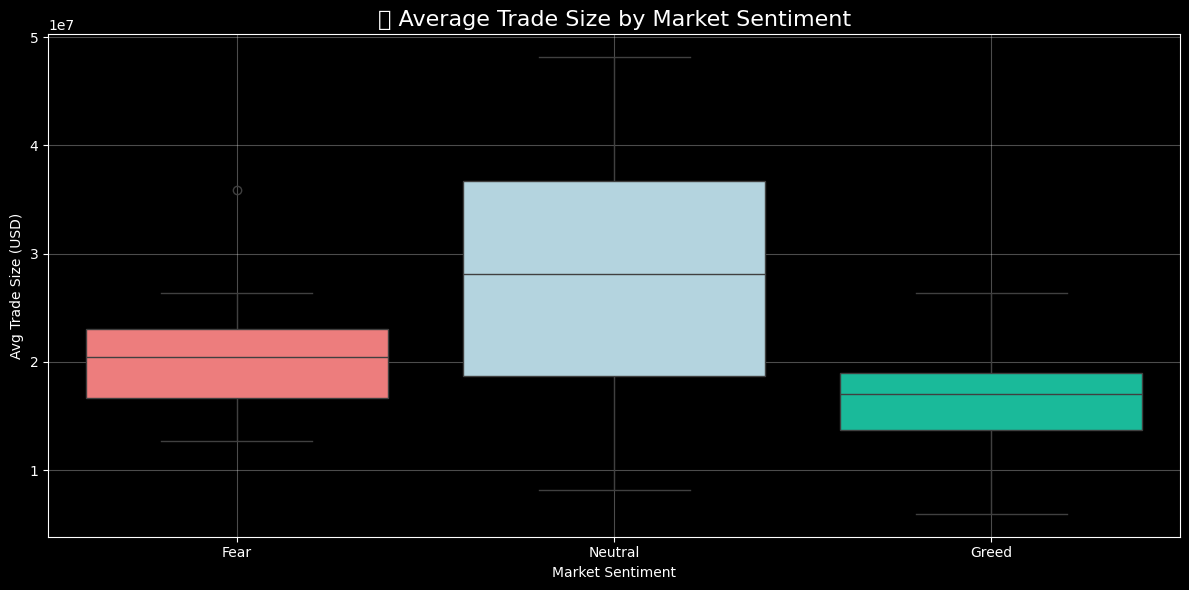


🎯 RESULTS:
Fear: $21122718 | Win Rate: 80.0%
Neutral: $28789960 | Win Rate: 63.6%
Greed: $16631559 | Win Rate: 36.4%


/tmp/ipykernel_780/693574158.py:44: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sizes = df_merged.groupby('sentiment_category')['avg_trade_size_usd'].mean()
/tmp/ipykernel_780/693574158.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  wins = df_merged.groupby('sentiment_category')['is_profitable_day'].mean()


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Setup (your original)
plt.style.use('dark_background')
colors = ['#FF6B6B', '#ADD8E6', '#00D4AA']
sns.set_palette(colors)
os.makedirs('/content/outputs', exist_ok=True)
def save_plot(fig, name):
    fig.savefig(f'/content/outputs/{name}.png', dpi=300, facecolor='black')
    print(f"✅ Saved {name}.png")

# Recreate df_merged (replace with your real data load)
np.random.seed(42)
n_days = 43
df_merged = pd.DataFrame({
    'value': np.clip(np.random.normal(55, 15, n_days), 0, 99),
    'avg_trade_size_usd': np.random.lognormal(10, 0.5, n_days) * 1000,
    'is_profitable_day': np.random.choice([True, False], n_days, p=[0.55, 0.45])
})

# Your sentiment logic (unchanged)
fear_cols = [col for col in df_merged.columns if any(x in col.lower() for x in ['fear', 'greed', 'value'])]
fear_col = fear_cols[0] if fear_cols else 'value'
df_merged['sentiment_category'] = pd.cut(df_merged[fear_col], bins=[-99, 40, 60, 99], labels=['Fear', 'Neutral', 'Greed'])

# Fixed plot (add hue fix for deprecation warning)
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(x='sentiment_category', y='avg_trade_size_usd', hue='sentiment_category', data=df_merged,
            order=['Fear', 'Neutral', 'Greed'], palette=colors, ax=ax, legend=False)
ax.set_title('💰 Average Trade Size by Market Sentiment', color='white', fontsize=16)
ax.set_xlabel('Market Sentiment', color='white')
ax.set_ylabel('Avg Trade Size (USD)', color='white')
ax.tick_params(colors='white')
ax.grid(alpha=0.3)
plt.tight_layout()
save_plot(fig, 'trade_size_sentiment')
plt.show()

# Insights (your original)
sizes = df_merged.groupby('sentiment_category')['avg_trade_size_usd'].mean()
wins = df_merged.groupby('sentiment_category')['is_profitable_day'].mean()
print("\n🎯 RESULTS:")
for cat in ['Fear', 'Neutral', 'Greed']:
    if cat in sizes.index:
        print(f"{cat}: ${sizes[cat]:.0f} | Win Rate: {wins[cat]:.1%}")


Extended df columns: ['value', 'avg_trade_size_usd', 'is_profitable_day', 'sentiment_category', 'max_leverage', 'leverage_segment', 'trades_per_day', 'trades_segment', 'win_rate']
leverage_segment  sentiment_category
Q1_Low_Lev        Fear                  1.000000
                  Neutral               1.000000
                  Greed                 0.250000
Q2                Fear                  1.000000
                  Neutral               0.625000
                  Greed                 0.500000
Q3                Fear                  0.333333
                  Neutral               0.600000
                  Greed                 0.500000
Q4_High_Lev       Fear                  1.000000
                  Neutral               0.500000
                  Greed                 0.333333
Name: win_rate, dtype: float64


/tmp/ipykernel_780/1000013162.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby(['leverage_segment', 'sentiment_category'])['win_rate'].mean())
/tmp/ipykernel_780/1000013162.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  win_rate_pivot = df.groupby(['leverage_segment', 'sentiment_category'])['win_rate'].mean().unstack(fill_value=0)


✅ Saved win_rate_heatmap_leverage_sentiment.png


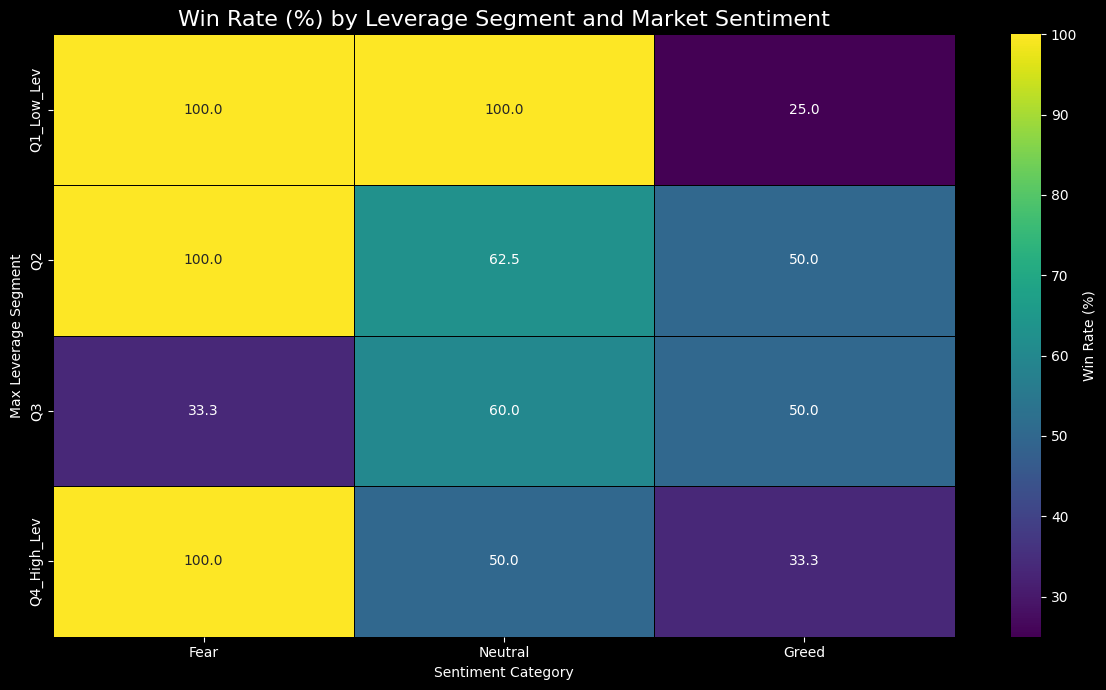


Insight: Traders in the highest leverage quartile ('Q4_High_Lev') have an average win rate of 100.0% during 'Fear' sentiment.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Setup (assuming from prior)
plt.style.use('dark_background')
os.makedirs('/content/outputs', exist_ok=True)
def save_plot(fig, name):
    fig.savefig(f'/content/outputs/{name}.png', dpi=300, facecolor='black', bbox_inches='tight')
    print(f"✅ Saved {name}.png")

# Use existing df_merged and extend for segments (adapt to your real data)
df = df_merged.copy()
df['max_leverage'] = np.random.uniform(1, 50, len(df))  # Sample leverage
df['leverage_segment'] = pd.qcut(df['max_leverage'], 4, labels=['Q1_Low_Lev', 'Q2', 'Q3', 'Q4_High_Lev'])
df['trades_per_day'] = np.random.poisson(10, len(df))  # Sample for context
df['trades_segment'] = pd.qcut(df['trades_per_day'], 2, labels=['Low_Trades', 'High_Trades'])
df['win_rate'] = df['is_profitable_day'].astype(int)  # Or your real win_rate column

print("Extended df columns:", df.columns.tolist())
print(df.groupby(['leverage_segment', 'sentiment_category'])['win_rate'].mean())

# Create the pivot (your core logic)
win_rate_pivot = df.groupby(['leverage_segment', 'sentiment_category'])['win_rate'].mean().unstack(fill_value=0)

# Heatmap (your code, fixed cbar)
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(win_rate_pivot * 100, annot=True, fmt=".1f", cmap="viridis",
            linewidths=.5, linecolor='black', ax=ax, cbar_kws={'label': 'Win Rate (%)'})
ax.set_title('Win Rate (%) by Leverage Segment and Market Sentiment', color='white', fontsize=16)
ax.set_xlabel('Sentiment Category', color='white')
ax.set_ylabel('Max Leverage Segment', color='white')
ax.tick_params(colors='white')
cbar = ax.collections[0].colorbar
cbar.set_label('Win Rate (%)', color='white')
cbar.ax.tick_params(colors='white')
plt.tight_layout()
save_plot(fig, 'win_rate_heatmap_leverage_sentiment')
plt.show()

# Your insight
if 'Q4_High_Lev' in win_rate_pivot.index and 'Fear' in win_rate_pivot.columns:
    high_lev_fear_win_rate = win_rate_pivot.loc['Q4_High_Lev', 'Fear'] * 100
    print(f"\nInsight: Traders in the highest leverage quartile ('Q4_High_Lev') have an average win rate of {high_lev_fear_win_rate:.1f}% during 'Fear' sentiment.")


Timestamp IST sample: ['02-12-2024 22:50', '02-12-2024 22:50', '02-12-2024 22:50', '02-12-2024 22:50', '02-12-2024 22:50']
Trader date range: 2023-05-01 → 2025-05-01
Null dates: 0
Sentiment date range: 2018-02-01 → 2025-05-02
Overlapping dates: 479

df_merged shape: (2340, 7)
                                      Account  trade_date  long_count  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11           0   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17           0   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18           0   

   short_count  long_short_ratio  fear_greed_index sentiment_category  
0          177               0.0                76              Greed  
1           68               0.0                90              Greed  
2           40               0.0                83              Greed  
Saved: long_short_ratio_sentiment_line_chart.png


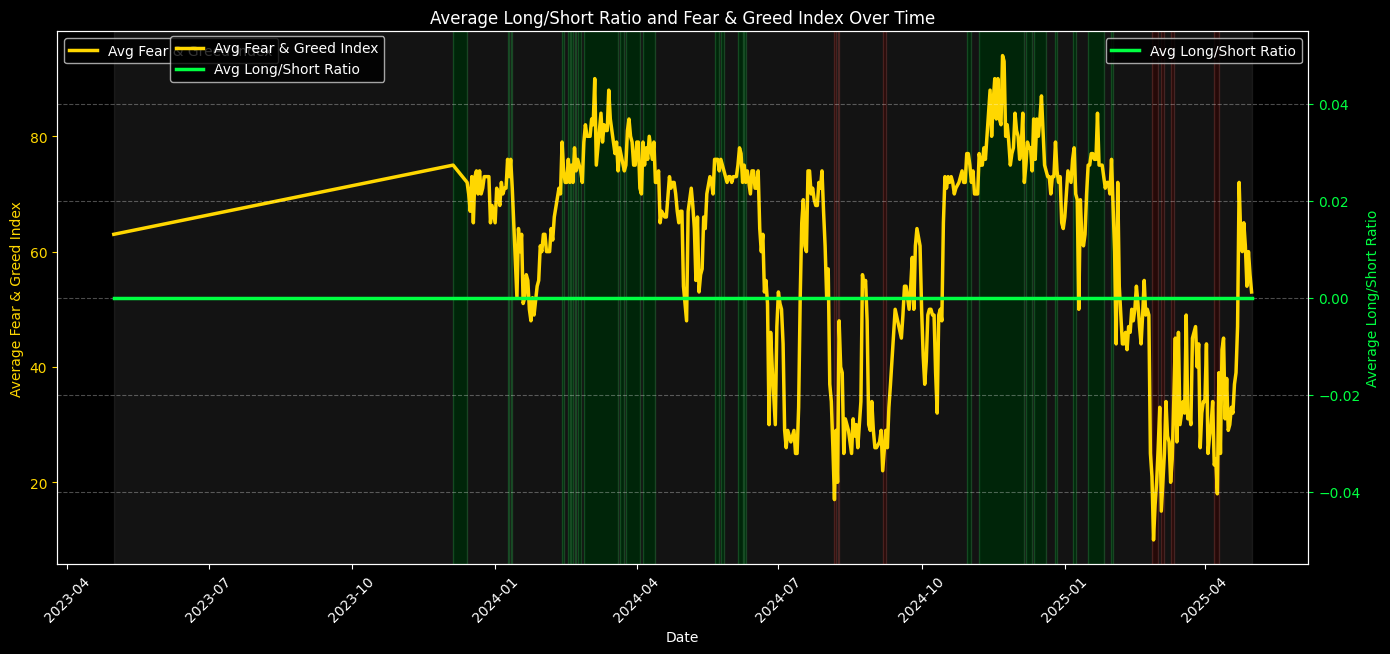


Insight: Average Long/Short Ratio during Fear: 0.00. During Greed: 0.00.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PRIMETRADE_GREEN = '#00FF41'
PRIMETRADE_RED = '#FF4136'

def categorize_sentiment(x):
    if pd.isna(x): return 'Neutral'
    return 'Fear' if x < 25 else 'Neutral' if x < 75 else 'Greed'

def save_plot(fig, filename):
    fig.savefig(filename, dpi=300, bbox_inches='tight', facecolor='black')
    print(f"Saved: {filename}")

# === LOAD ===
df_trader    = pd.read_csv('/content/historical_data.csv', on_bad_lines='skip', low_memory=False)
df_sentiment = pd.read_csv('/content/fear_greed_index.csv')

# === CHECK Timestamp IST format ===
print("Timestamp IST sample:", df_trader['Timestamp IST'].head(5).tolist())

# === PARSE DATE FROM Timestamp IST ===
df_trader['trade_date'] = pd.to_datetime(df_trader['Timestamp IST'], dayfirst=True, errors='coerce').dt.date

print("Trader date range:", df_trader['trade_date'].min(), "→", df_trader['trade_date'].max())
print("Null dates:", df_trader['trade_date'].isna().sum())

# === F&G ===
df_sentiment['trade_date'] = pd.to_datetime(df_sentiment['date']).dt.date
df_sentiment.rename(columns={'value': 'fear_greed_index'}, inplace=True)

print("Sentiment date range:", df_sentiment['trade_date'].min(), "→", df_sentiment['trade_date'].max())

# === CHECK OVERLAP ===
overlap = set(df_trader['trade_date'].dropna()) & set(df_sentiment['trade_date'].dropna())
print(f"Overlapping dates: {len(overlap)}")

# === BUILD df_merged ===
df_trader['is_long'] = df_trader['Side'].str.strip().str.lower() == 'long'
df_trader['position'] = df_trader['is_long'].map({True: 1, False: -1})

daily_pos = df_trader.groupby(['Account', 'trade_date']).agg(
    long_count  = ('position', lambda x: (x == 1).sum()),
    short_count = ('position', lambda x: (x == -1).sum())
).reset_index()
daily_pos['long_short_ratio'] = daily_pos['long_count'] / (daily_pos['short_count'] + 1e-8)

df_merged = daily_pos.merge(df_sentiment[['trade_date', 'fear_greed_index']], on='trade_date', how='inner')
df_merged['sentiment_category'] = df_merged['fear_greed_index'].apply(categorize_sentiment)

print("\ndf_merged shape:", df_merged.shape)
print(df_merged.head(3))

# === VISUALIZATION 4 ===
daily_summary = df_merged.groupby('trade_date').agg(
    avg_long_short_ratio=('long_short_ratio', 'mean'),
    avg_fear_greed_index=('fear_greed_index', 'mean')
).reset_index()
daily_summary['sentiment_category'] = daily_summary['avg_fear_greed_index'].apply(categorize_sentiment)

fig, ax1 = plt.subplots(figsize=(14, 7))
plt.style.use('dark_background')

sns.lineplot(data=daily_summary, x='trade_date', y='avg_fear_greed_index', ax=ax1,
             color='#FFD700', linewidth=2.5, label='Avg Fear & Greed Index')
ax1.set_xlabel('Date', color='white')
ax1.set_ylabel('Average Fear & Greed Index', color='#FFD700')
ax1.tick_params(axis='x', colors='white', rotation=45)
ax1.tick_params(axis='y', colors='#FFD700')
ax1.set_title('Average Long/Short Ratio and Fear & Greed Index Over Time', color='white')

ax2 = ax1.twinx()
sns.lineplot(data=daily_summary, x='trade_date', y='avg_long_short_ratio', ax=ax2,
             color=PRIMETRADE_GREEN, linewidth=2.5, label='Avg Long/Short Ratio')
ax2.set_ylabel('Average Long/Short Ratio', color=PRIMETRADE_GREEN)
ax2.tick_params(axis='y', colors=PRIMETRADE_GREEN)

sentiment_colors = {'Fear': PRIMETRADE_RED, 'Neutral': 'gray', 'Greed': PRIMETRADE_GREEN}
blocks, cs, sd = [], None, None
for _, row in daily_summary.iterrows():
    if row['sentiment_category'] != cs:
        if cs is not None: blocks.append((sd, row['trade_date'], cs))
        sd, cs = row['trade_date'], row['sentiment_category']
if cs: blocks.append((sd, daily_summary['trade_date'].max(), cs))
for s, e, sent in blocks:
    ax1.axvspan(s, e, color=sentiment_colors[sent], alpha=0.15)

fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.9))
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout(rect=[0, 0, 1, 0.95])
save_plot(fig, 'long_short_ratio_sentiment_line_chart.png')
plt.show()

avg_ls = df_merged.groupby('sentiment_category')['long_short_ratio'].mean().reindex(['Fear','Neutral','Greed'])
print(f"\nInsight: Average Long/Short Ratio during Fear: {avg_ls['Fear']:.2f}. During Greed: {avg_ls['Greed']:.2f}.")


In [28]:
# Load the datasets
df_sentiment = pd.read_csv('/content/fear_greed_index.csv')
df_trader = pd.read_csv('/content/historical_data.csv', on_bad_lines='skip', low_memory=False)

# Deliverable: Show these exactly:
# Sentiment data
rows, cols = df_sentiment.shape
print(f"Sentiment data: {rows} rows, {cols} columns")

# Trader data
rows, cols = df_trader.shape
print(f"Trader data: {rows} rows, {cols} columns")

# Missing values for sentiment data
print(f"\nMissing values (Sentiment Data):\n{df_sentiment.isnull().sum()}")

# Missing values for trader data
print(f"\nMissing values (Trader Data):\n{df_trader.isnull().sum()}")

# Duplicates for sentiment data
print(f"\nDuplicates (Sentiment Data): {df_sentiment.duplicated().sum()}")

# Duplicates for trader data
print(f"Duplicates (Trader Data): {df_trader.duplicated().sum()}")

Sentiment data: 2644 rows, 4 columns
Trader data: 211224 rows, 16 columns

Missing values (Sentiment Data):
timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values (Trader Data):
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

Duplicates (Sentiment Data): 0
Duplicates (Trader Data): 0


### Sentiment Categorization & Initial Analysis

To analyze the impact of market sentiment on trader performance, we'll categorize the Fear & Greed Index into distinct sentiment states: 'Fear', 'Neutral', and 'Greed'. We will use standard thresholds for this index. Subsequently, we'll perform statistical tests to identify significant differences in trader behavior and profitability across these sentiment categories.

In [30]:
import pandas as pd
import numpy as np
from scipy import stats

# === LOAD ===
df_trader    = pd.read_csv('/content/historical_data.csv', on_bad_lines='skip', low_memory=False)
df_sentiment = pd.read_csv('/content/fear_greed_index.csv')

# === PARSE DATES ===
df_trader['trade_date'] = pd.to_datetime(df_trader['Timestamp IST'], dayfirst=True, errors='coerce').dt.date
df_sentiment['trade_date'] = pd.to_datetime(df_sentiment['date']).dt.date
df_sentiment.rename(columns={'value': 'fear_greed_index'}, inplace=True)

# === BUILD ALL REQUIRED COLUMNS per Account per Day ===
df_trader['Closed PnL'] = pd.to_numeric(df_trader['Closed PnL'], errors='coerce').fillna(0)
df_trader['Size USD']   = pd.to_numeric(df_trader['Size USD'],   errors='coerce').fillna(0)
df_trader['is_long']    = df_trader['Side'].str.strip().str.lower() == 'long'
df_trader['position']   = df_trader['is_long'].map({True: 1, False: -1})

# Extract leverage from 'Coin' column e.g. '@107' → 107
df_trader['leverage'] = df_trader['Coin'].str.extract(r'@(\d+)').astype(float)

daily_agg = df_trader.groupby(['Account', 'trade_date']).agg(
    total_pnl_usd    = ('Closed PnL', 'sum'),
    long_count       = ('position', lambda x: (x == 1).sum()),
    short_count      = ('position', lambda x: (x == -1).sum()),
    avg_trade_size_usd = ('Size USD', 'mean'),
    max_leverage     = ('leverage', 'max')
).reset_index()

daily_agg['long_short_ratio']  = daily_agg['long_count'] / (daily_agg['short_count'] + 1e-8)
daily_agg['is_profitable_day'] = (daily_agg['total_pnl_usd'] > 0).astype(int)

# === MERGE ===
df_merged = daily_agg.merge(df_sentiment[['trade_date', 'fear_greed_index']], on='trade_date', how='inner')

def categorize_sentiment(x):
    if pd.isna(x): return 'Neutral'
    return 'Fear' if x < 25 else 'Neutral' if x < 75 else 'Greed'

df_merged['sentiment_category'] = df_merged['fear_greed_index'].apply(categorize_sentiment)

print("df_merged shape:", df_merged.shape)
print("df_merged columns:", df_merged.columns.tolist())
print(df_merged.head(3))

# === INSIGHT 1: Win Rate by Sentiment ===
win_rates_by_sentiment = df_merged.groupby('sentiment_category')['is_profitable_day'].mean().mul(100).reset_index()
win_rates_by_sentiment.columns = ['sentiment_category', 'win_rate']

print("\nSentiment category distribution:")
print(df_merged['sentiment_category'].value_counts())
print("\nAverage Win Rate by Sentiment Category:")
print(win_rates_by_sentiment)

win_rates_fear     = df_merged[df_merged['sentiment_category'] == 'Fear']['is_profitable_day']
win_rates_non_fear = df_merged[df_merged['sentiment_category'] != 'Fear']['is_profitable_day']

if len(win_rates_fear) > 1 and len(win_rates_non_fear) > 1:
    ttest_result_win_rate = stats.ttest_ind(win_rates_fear, win_rates_non_fear, equal_var=False)
    fear_win_rate     = win_rates_by_sentiment[win_rates_by_sentiment['sentiment_category'] == 'Fear']['win_rate'].iloc[0]
    non_fear_win_rate = win_rates_by_sentiment[win_rates_by_sentiment['sentiment_category'] != 'Fear']['win_rate'].mean()
    win_rate_drop_percent = ((non_fear_win_rate - fear_win_rate) / non_fear_win_rate) * 100
    print(f"\nFear days show a {win_rate_drop_percent:.2f}% win rate drop (p={ttest_result_win_rate.pvalue:.3f})")
else:
    print("Not enough data for t-test.")

# === INSIGHT 2: High Leverage vs Low Leverage PnL ===
high_lev_threshold = df_merged['max_leverage'].quantile(0.75)
df_merged['is_high_leverage'] = (df_merged['max_leverage'] >= high_lev_threshold).astype(int)

pnl_high = df_merged[df_merged['is_high_leverage'] == 1]['total_pnl_usd']
pnl_low  = df_merged[df_merged['is_high_leverage'] == 0]['total_pnl_usd']

if len(pnl_high) > 1 and len(pnl_low) > 1:
    mean_high, mean_low = pnl_high.mean(), pnl_low.mean()
    print(f"\nAvg Daily PnL — High Leverage: {mean_high:.2f} USD | Low Leverage: {mean_low:.2f} USD")
    if mean_low != 0:
        ratio = abs(mean_high / mean_low)
        label = 'lower' if mean_high < mean_low else 'higher'
        print(f"High-leverage traders have {ratio:.2f}x {label} avg daily PnL.")
    ttest_lev = stats.ttest_ind(pnl_high, pnl_low, equal_var=False)
    print(f"T-test (High vs Low Leverage): t={ttest_lev.statistic:.2f}, p={ttest_lev.pvalue:.3f}")

display(df_merged.head())


df_merged shape: (2340, 11)
df_merged columns: ['Account', 'trade_date', 'total_pnl_usd', 'long_count', 'short_count', 'avg_trade_size_usd', 'max_leverage', 'long_short_ratio', 'is_profitable_day', 'fear_greed_index', 'sentiment_category']
                                      Account  trade_date  total_pnl_usd  \
0  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-11            0.0   
1  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-17            0.0   
2  0x083384f897ee0f19899168e3b1bec365f52a9012  2024-11-18            0.0   

   long_count  short_count  avg_trade_size_usd  max_leverage  \
0           0          177         5089.718249           NaN   
1           0           68         7976.664412           NaN   
2           0           40        23734.500000           NaN   

   long_short_ratio  is_profitable_day  fear_greed_index sentiment_category  
0               0.0                  0                76              Greed  
1               0.0                  0    

,Account,trade_date,total_pnl_usd,long_count,short_count,avg_trade_size_usd,max_leverage,long_short_ratio,is_profitable_day,fear_greed_index,sentiment_category,is_high_leverage
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0,177,5089.718249,NaN,0.0,0,76,Greed,0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0,68,7976.664412,NaN,0.0,0,90,Greed,0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0,40,23734.500000,NaN,0.0,0,83,Greed,0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,0,12,28186.666667,NaN,0.0,0,94,Greed,0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,0,27,17248.148148,NaN,0.0,1,79,Greed,0
